# 1. Configuración del proyecto

En este cuadernillo se desarrolla una **GAN condicional (cGAN)** para generar imágenes de 37 clases diferentes de insectos.

La auditoría del dataset se realizó previamente en un cuadernillo independiente. Se utilizará el mismo dataset, compuesto por aproximadamente 37.000 imágenes RGB de 200×200 píxeles.

Para este laboratorio se trabajará con una resolución de **128×128 píxeles**, buscando un equilibrio entre calidad visual y costo computacional.

La GAN será condicional: el Generador recibe ruido aleatorio y una etiqueta de clase para producir un insecto de la categoría indicada.


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# =========================
# CONFIGURACIÓN
# =========================

DATASET_PATH = r"D:\Universidad\6to Semestre\Inteligencia Artificial 2\Laboratorios\Inteligencia-Artificial-2\Laboratorios\Laboratorio 4\Dataset\DATASET_FINAL\DATASET_FINAL"

IMAGE_SIZE = 128
BATCH_SIZE = 32

NUM_CLASSES = 37
LATENT_DIM = 100
EMBEDDING_DIM = 50

LR = 0.0002
BETA1 = 0.5

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)


Dispositivo: cpu


## 2. Carga y preprocesamiento del dataset

Las imágenes se cargan mediante `ImageFolder`, que interpreta cada subcarpeta como una clase.

El preprocesamiento:

1. Redimensiona a **128×128**.
2. Convierte las imágenes a tensores.
3. Normaliza los canales RGB al rango aproximado `[-1, 1]`.

Esto coincide con el rango de salida de `Tanh`, que utilizaremos en el Generador.

El `DataLoader` utiliza lotes de 32 imágenes y mezcla las muestras.


In [18]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Imágenes:", len(dataset))
print("Clases:", len(dataset.classes))
print("Tamaño:", IMAGE_SIZE, "x", IMAGE_SIZE)
print(dataset.class_to_idx)


Imágenes: 37000
Clases: 37
Tamaño: 128 x 128
{'Aricia_agestis_artaxerxes': 0, 'Chiasmia_clathrata': 1, 'Cicadella viridis': 2, 'Cicadellidae': 3, 'Coenonympha_pamphilus': 4, 'Cupido_minimus': 5, 'Danaus_plexippus': 6, 'Gonepteryx_rhamni': 7, 'Hymenoptera': 8, 'Lepidoptera': 9, 'Leptoglossus_occidentalis': 10, 'Limacodidae': 11, 'Lycaena_phlaeas': 12, 'Lycorma delicatula': 13, 'Macroglossum_stellatarum': 14, 'Meloidae': 15, 'Miridae': 16, 'Noctua_pronuba': 17, 'Ochlodes_sylvanus': 18, 'Pieris_napi': 19, 'Pieris_rapae': 20, 'Polyommatus_icarus': 21, 'Psocodea': 22, 'Rhaphigaster_nebulosa': 23, 'Thymelicus_lineola': 24, 'Thymelicus_sylvestris': 25, 'abejas': 26, 'arañas': 27, 'avispas': 28, 'cucarachas': 29, 'dragonfly': 30, 'fly': 31, 'hormigas': 32, 'ladybug': 33, 'mantis': 34, 'mosquitos': 35, 'saltamontes': 36}


# 3. Generador

El Generador aprende a transformar ruido aleatorio en imágenes de insectos.

Al ser condicional, recibe:

- **Ruido:** permite generar diferentes ejemplos.
- **Etiqueta:** indica qué clase de insecto queremos producir.

La etiqueta pasa por un `Embedding` de 50 dimensiones y se concatena con el ruido de 100 dimensiones.

Las capas `ConvTranspose2d` aumentan progresivamente la resolución:

`4×4 → 8×8 → 16×16 → 32×32 → 64×64 → 128×128`

Se utiliza `BatchNorm2d` para ayudar a estabilizar el entrenamiento, `ReLU` en las capas internas y `Tanh` en la salida.


In [19]:
class Generator(nn.Module):

    def __init__(
        self,
        latent_dim=100,
        num_classes=37,
        embedding_dim=50
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.model = nn.Sequential(
            # 150 × 1 × 1 → 512 × 4 × 4
            nn.ConvTranspose2d(
                latent_dim + embedding_dim,
                512, 4, 1, 0, bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 4 → 8
            nn.ConvTranspose2d(
                512, 256, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8 → 16
            nn.ConvTranspose2d(
                256, 128, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16 → 32
            nn.ConvTranspose2d(
                128, 64, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32 → 64
            nn.ConvTranspose2d(
                64, 32, 4, 2, 1, bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # 64 → 128
            nn.ConvTranspose2d(
                32, 3, 4, 2, 1, bias=False
            ),
            nn.Tanh()
        )

    def forward(self, noise, labels):

        class_embedding = self.embedding(labels)
        class_embedding = class_embedding.unsqueeze(2).unsqueeze(3)

        x = torch.cat(
            [noise, class_embedding],
            dim=1
        )

        return self.model(x)


In [20]:
generator = Generator(
    LATENT_DIM,
    NUM_CLASSES,
    EMBEDDING_DIM
).to(device)

noise = torch.randn(
    BATCH_SIZE,
    LATENT_DIM,
    1,
    1,
    device=device
)

labels = torch.randint(
    0,
    NUM_CLASSES,
    (BATCH_SIZE,),
    device=device
)

fake_images = generator(noise, labels)

print("Ruido:", noise.shape)
print("Etiquetas:", labels.shape)
print("Imágenes generadas:", fake_images.shape)


Ruido: torch.Size([32, 100, 1, 1])
Etiquetas: torch.Size([32])
Imágenes generadas: torch.Size([32, 3, 128, 128])


# 4. Discriminador condicional

El Discriminador recibe una imagen y la etiqueta que supuestamente corresponde a ella.

Su objetivo es distinguir entre imágenes reales y generadas.

La imagen se procesa mediante capas convolucionales:

`128×128 → 64×64 → 32×32 → 16×16 → 8×8 → 4×4`

La etiqueta se transforma mediante otro `Embedding`. Las características visuales y la información de clase se combinan antes de la clasificación final.

La salida es un único **logit**. No se utiliza `Sigmoid` porque `BCEWithLogitsLoss` lo incorpora internamente.


In [21]:
class Discriminator(nn.Module):

    def __init__(
        self,
        num_classes=37,
        embedding_dim=50
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        self.image_features = nn.Sequential(
            # 128 → 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 → 32
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 4
            nn.Conv2d(512, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.classifier = nn.Linear(
            512 * 4 * 4 + embedding_dim,
            1
        )

    def forward(self, images, labels):

        image_features = self.image_features(images)
        image_features = image_features.view(
            image_features.size(0), -1
        )

        class_features = self.embedding(labels)

        combined = torch.cat(
            [image_features, class_features],
            dim=1
        )

        return self.classifier(combined)


In [22]:
discriminator = Discriminator(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBEDDING_DIM
).to(device)

print(discriminator)


Discriminator(
  (embedding): Embedding(37, 50)
  (image_features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 512, kernel_size=(4, 4), strid

## 4.1. Prueba del Discriminador

Comprobamos que el Discriminador puede recibir correctamente imágenes reales del dataset.

Esperamos:

- Imágenes: `[32, 3, 128, 128]`
- Etiquetas: `[32]`
- Predicción: `[32, 1]`


In [23]:
real_images, real_labels = next(iter(dataloader))

real_images = real_images.to(device)
real_labels = real_labels.to(device)

output_real = discriminator(
    real_images,
    real_labels
)

print("Imágenes reales:", real_images.shape)
print("Etiquetas:", real_labels.shape)
print("Predicciones:", output_real.shape)
print(output_real[:10])


Imágenes reales: torch.Size([32, 3, 128, 128])
Etiquetas: torch.Size([32])
Predicciones: torch.Size([32, 1])
tensor([[-0.1039],
        [ 0.1127],
        [ 0.4204],
        [ 0.4531],
        [ 0.2952],
        [-0.0752],
        [ 0.3613],
        [-0.0649],
        [ 0.3311],
        [-0.6691]], grad_fn=<SliceBackward0>)


## 4.2. Prueba con imágenes generadas

Comprobamos el flujo completo:

`ruido + clase → Generador → imagen falsa → Discriminador`


In [24]:
noise = torch.randn(
    BATCH_SIZE,
    LATENT_DIM,
    1,
    1,
    device=device
)

fake_labels = torch.randint(
    0,
    NUM_CLASSES,
    (BATCH_SIZE,),
    device=device
)

fake_images = generator(
    noise,
    fake_labels
)

output_fake = discriminator(
    fake_images,
    fake_labels
)

print("Imágenes falsas:", fake_images.shape)
print("Etiquetas:", fake_labels.shape)
print("Predicciones:", output_fake.shape)


Imágenes falsas: torch.Size([32, 3, 128, 128])
Etiquetas: torch.Size([32])
Predicciones: torch.Size([32, 1])


# 5. Función de pérdida

Utilizaremos `BCEWithLogitsLoss`.

El Discriminador aprende a clasificar:

- imagen real → `1`
- imagen falsa → `0`

El Generador intenta que sus imágenes sean clasificadas como reales.

`BCEWithLogitsLoss` combina internamente la función sigmoide con la entropía cruzada binaria de forma numéricamente estable.


In [25]:
criterion = nn.BCEWithLogitsLoss()


## 5.1. Optimizadores

Cada red posee su propio optimizador Adam porque sus parámetros se actualizan de manera independiente.

Utilizamos una tasa de aprendizaje de `0.0002` y `betas=(0.5, 0.999)` como configuración inicial.


In [26]:
optimizer_G = optim.Adam(
    generator.parameters(),
    lr=LR,
    betas=(BETA1, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=LR,
    betas=(BETA1, 0.999)
)


## 5.2. Regularización y estabilidad

Las GAN pueden ser inestables porque el Generador y el Discriminador compiten durante el entrenamiento.

En este modelo utilizaremos técnicas sencillas:

- **Batch Normalization:** ayuda a estabilizar las activaciones.
- **LeakyReLU:** mantiene gradientes para activaciones negativas en el Discriminador.
- **Label smoothing:** las imágenes reales utilizarán `0.9` en lugar de `1.0`, evitando que el Discriminador se vuelva demasiado confiado.

Estas técnicas mantienen el modelo relativamente sencillo y fácil de explicar.


In [27]:
REAL_LABEL = 0.9
FAKE_LABEL = 0.0

print("Etiqueta real:", REAL_LABEL)
print("Etiqueta falsa:", FAKE_LABEL)


Etiqueta real: 0.9
Etiqueta falsa: 0.0


## 5.3. Reproducibilidad y almacenamiento

Se establece una semilla para facilitar la reproducción del experimento.

También se crean carpetas para almacenar las muestras generadas y los checkpoints del modelo.


In [28]:
import os
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs("samples", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)


# 6. Preparación del entrenamiento

Usaremos ruido fijo para comparar visualmente el progreso del Generador.

Se utilizará el mismo ruido y las mismas etiquetas en cada evaluación. Así podemos observar cómo cambia la calidad de las imágenes a medida que avanzan las épocas.


In [29]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

NUM_EPOCHS = 30

FIXED_NOISE = torch.randn(
    NUM_CLASSES,
    LATENT_DIM,
    1,
    1,
    device=device
)

FIXED_LABELS = torch.arange(
    NUM_CLASSES,
    device=device
)

losses_G = []
losses_D = []


## 6.1. Guardado de muestras

Después de cada época generaremos una imagen para cada una de las 37 clases.

Los valores se convierten de `[-1, 1]` a `[0, 1]` solamente para guardar y visualizar las imágenes.


In [30]:
def save_generated_samples(epoch):

    generator.eval()

    with torch.no_grad():
        images = generator(FIXED_NOISE, FIXED_LABELS)

    images = (images + 1) / 2
    grid = make_grid(images, nrow=5)
    save_image(grid, f"samples/epoch_{epoch:03d}.png")

    generator.train()



# 7. Entrenamiento de la GAN

El entrenamiento alterna dos pasos.

### Discriminador
Aprende con imágenes reales y falsas.

### Generador
Aprende a producir imágenes que el Discriminador clasifique como reales.

Cuando se entrena el Discriminador, `detach()` evita que esa actualización modifique los parámetros del Generador.


In [31]:
for epoch in range(1, NUM_EPOCHS + 1):

    running_loss_G = 0.0
    running_loss_D = 0.0

    running_D_real = 0.0
    running_D_fake = 0.0

    for real_images, real_labels in dataloader:

        real_images = real_images.to(device)
        real_labels = real_labels.to(device)
        batch_size = real_images.size(0)

        # ==========================================
        # 1. ENTRENAR DISCRIMINADOR
        # ==========================================

        optimizer_D.zero_grad()

        output_real = discriminator(
            real_images,
            real_labels
        )

        labels_real = torch.full(
            (batch_size, 1),
            REAL_LABEL,
            device=device
        )

        loss_D_real = criterion(
            output_real,
            labels_real
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=device
        )

        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=device
        )

        fake_images = generator(
            noise,
            fake_labels
        )

        output_fake = discriminator(
            fake_images.detach(),
            fake_labels
        )

        labels_fake = torch.full(
            (batch_size, 1),
            FAKE_LABEL,
            device=device
        )

        loss_D_fake = criterion(
            output_fake,
            labels_fake
        )

        loss_D = loss_D_real + loss_D_fake

        loss_D.backward()
        optimizer_D.step()

        # Métricas del Discriminador
        # Convertimos los logits a probabilidades mediante sigmoid
        d_real = torch.sigmoid(output_real).mean().item()
        d_fake = torch.sigmoid(output_fake).mean().item()

        running_D_real += d_real
        running_D_fake += d_fake

        # ==========================================
        # 2. ENTRENAR GENERADOR
        # ==========================================

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            1,
            1,
            device=device
        )

        fake_labels = torch.randint(
            0,
            NUM_CLASSES,
            (batch_size,),
            device=device
        )

        fake_images = generator(
            noise,
            fake_labels
        )

        output_fake = discriminator(
            fake_images,
            fake_labels
        )

        labels_generator = torch.ones(
            (batch_size, 1),
            device=device
        )

        loss_G = criterion(
            output_fake,
            labels_generator
        )

        loss_G.backward()
        optimizer_G.step()

        running_loss_D += loss_D.item()
        running_loss_G += loss_G.item()

    avg_loss_D = running_loss_D / len(dataloader)
    avg_loss_G = running_loss_G / len(dataloader)

    avg_D_real = running_D_real / len(dataloader)
    avg_D_fake = running_D_fake / len(dataloader)

    losses_D.append(avg_loss_D)
    losses_G.append(avg_loss_G)

    d_real_history.append(avg_D_real)
    d_fake_history.append(avg_D_fake)

    save_generated_samples(epoch)

    torch.save(
        {
            "epoch": epoch,
            "generator_state_dict": generator.state_dict(),
            "discriminator_state_dict": discriminator.state_dict(),
            "optimizer_G_state_dict": optimizer_G.state_dict(),
            "optimizer_D_state_dict": optimizer_D.state_dict(),
            "loss_G": losses_G,
            "loss_D": losses_D,
            "D_real": d_real_history,
            "D_fake": d_fake_history
        },
        f"checkpoints/checkpoint_epoch_{epoch:03d}.pt"
    )

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"Loss D: {avg_loss_D:.4f} | "
        f"Loss G: {avg_loss_G:.4f} | "
        f"D(real): {avg_D_real:.4f} | "
        f"D(fake): {avg_D_fake:.4f}"
    )


Epoch [1/30] | Loss D: 0.7662 | Loss G: 4.0701 | D(real): 0.7369 | D(fake): 0.1628
Epoch [2/30] | Loss D: 0.8194 | Loss G: 3.4011 | D(real): 0.7068 | D(fake): 0.1905


KeyboardInterrupt: 

## 7.1. Evolución de las pérdidas

En una GAN las pérdidas no tienen que disminuir de forma monótona porque las dos redes tienen objetivos opuestos.

Por eso observaremos las pérdidas junto con las métricas del Discriminador.

### Métricas del Discriminador

- **D(real):** promedio de la probabilidad asignada a imágenes reales.
- **D(fake):** promedio de la probabilidad asignada a imágenes generadas.

Al principio esperamos que D(real) sea relativamente alto y D(fake) relativamente bajo. Si el Generador mejora, D(fake) debería aumentar porque las imágenes falsas empiezan a ser más difíciles de distinguir.

Estas métricas no deben interpretarse de manera aislada: una GAN busca un equilibrio entre ambas redes.


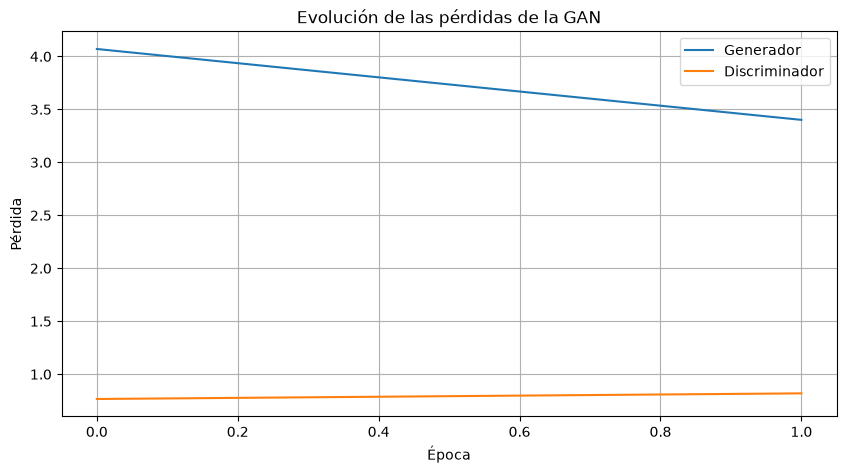

In [32]:
# Gráfica 1: pérdidas

plt.figure(figsize=(10, 5))

plt.plot(losses_G, label="Generador")
plt.plot(losses_D, label="Discriminador")

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de las pérdidas de la GAN")

plt.legend()
plt.grid(True)
plt.show()


### 7.2. Comportamiento del Discriminador

La siguiente gráfica muestra cómo cambia la confianza media del Discriminador frente a imágenes reales y falsas.

La salida del modelo es un **logit**, por lo que aplicamos `sigmoid` únicamente para interpretar el resultado como una probabilidad entre 0 y 1.

- Valores de **D(real)** cercanos a 1 indican que reconoce imágenes reales.
- Valores de **D(fake)** cercanos a 0 indican que reconoce imágenes generadas.
- Si D(fake) aumenta durante el entrenamiento, puede indicar que el Generador está produciendo imágenes más convincentes.


In [ ]:
# Gráfica 2: comportamiento del Discriminador

plt.figure(figsize=(10, 5))

plt.plot(d_real_history, label="D(real)")
plt.plot(d_fake_history, label="D(fake)")

plt.xlabel("Época")
plt.ylabel("Probabilidad promedio")
plt.title("Comportamiento del Discriminador")

plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


# 8. Evaluación visual

La consigna requiere demostrar que el modelo puede generar insectos. Por ello, la evaluación principal será visual.

Primero generaremos una imagen para cada una de las 37 clases.


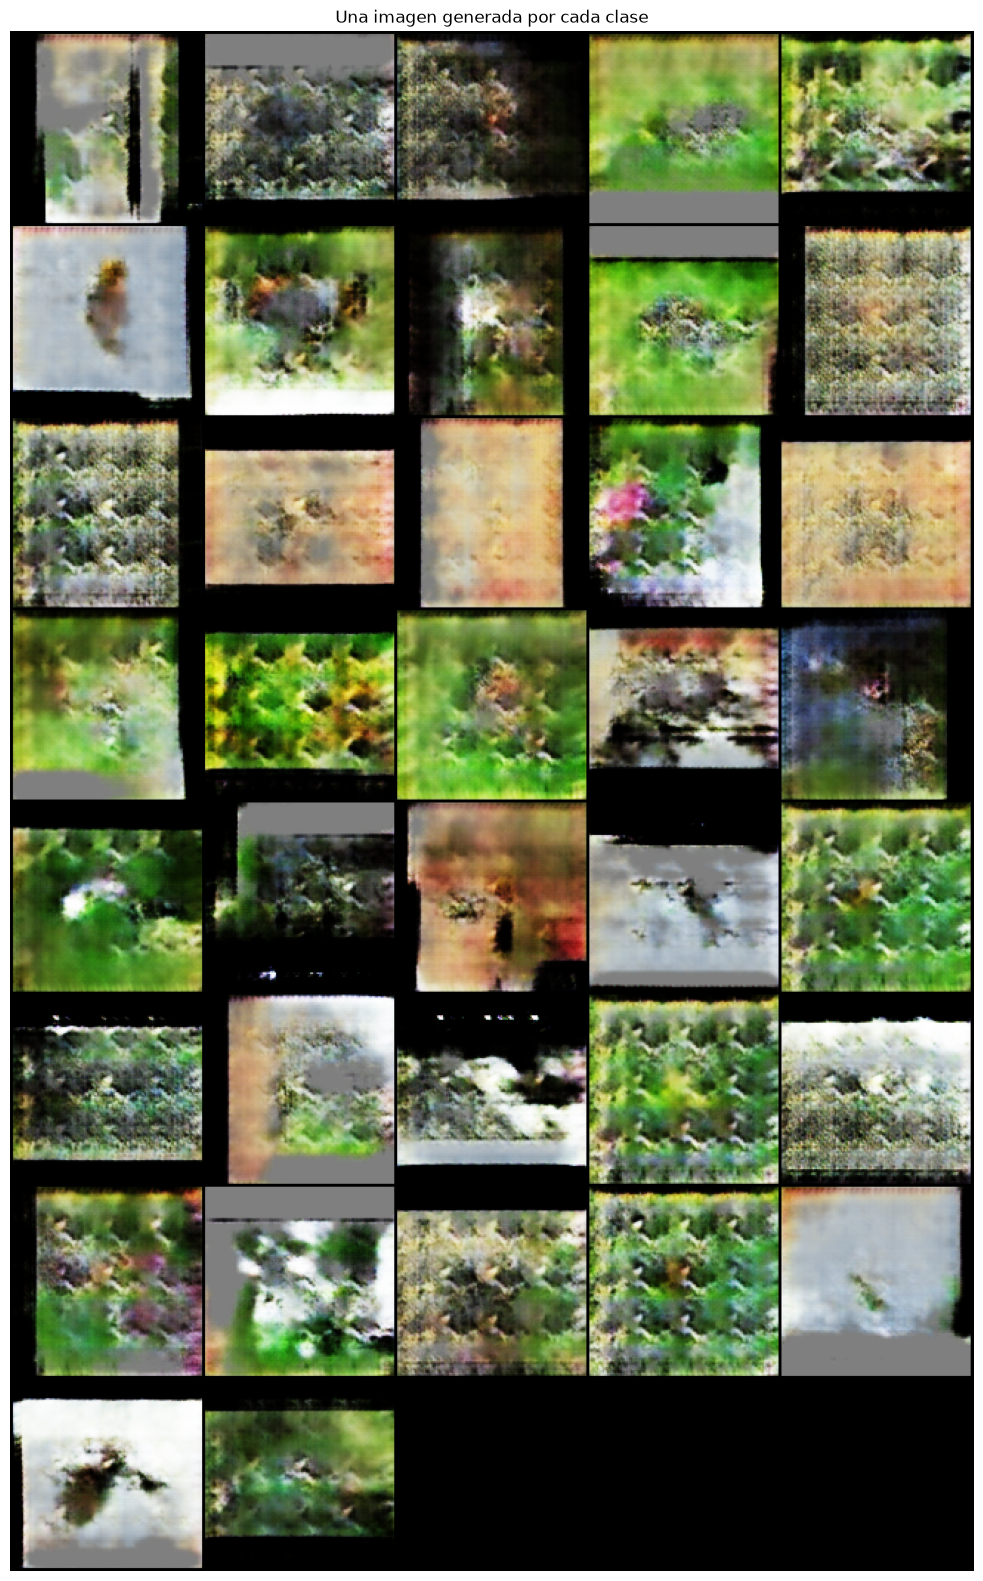

In [33]:
generator.eval()

with torch.no_grad():
    final_images = generator(
        FIXED_NOISE,
        FIXED_LABELS
    )

final_images = (final_images + 1) / 2

grid = make_grid(
    final_images,
    nrow=5
)

plt.figure(figsize=(15, 20))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("Una imagen generada por cada clase")
plt.show()


## 8.1. Diversidad dentro de una clase

Para comprobar que el ruido permite generar diferentes ejemplos, mantendremos una clase fija y cambiaremos el ruido.

Esto permite evaluar dos propiedades:

- **Condicionalidad:** la clase influye en el tipo de insecto generado.
- **Diversidad:** distintos ruidos producen diferentes ejemplos de la misma clase.


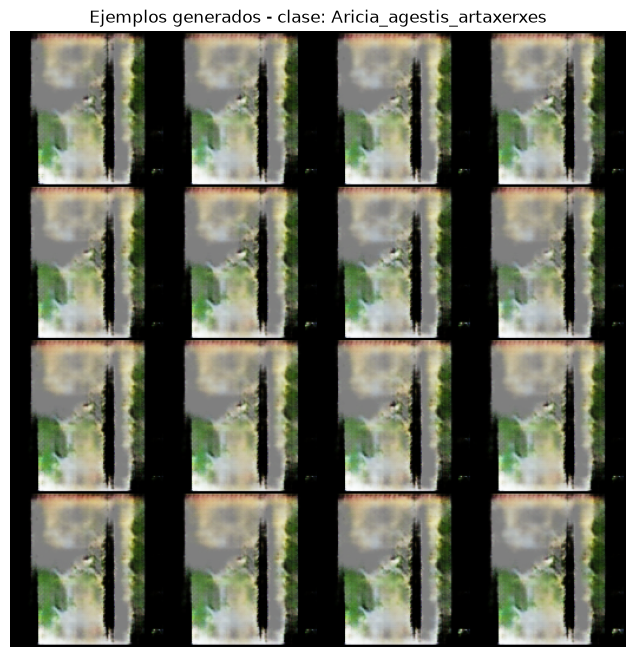

In [34]:
CLASS_INDEX = 0
NUM_SAMPLES = 16

sample_labels = torch.full(
    (NUM_SAMPLES,),
    CLASS_INDEX,
    dtype=torch.long,
    device=device
)

sample_noise = torch.randn(
    NUM_SAMPLES,
    LATENT_DIM,
    1,
    1,
    device=device
)

with torch.no_grad():
    class_images = generator(
        sample_noise,
        sample_labels
    )

class_images = (class_images + 1) / 2

grid = make_grid(
    class_images,
    nrow=4
)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title(
    f"Ejemplos generados - clase: {dataset.classes[CLASS_INDEX]}"
)
plt.show()


# 9. Conclusiones

El modelo implementado es una **GAN condicional** formada por un Generador y un Discriminador.

El Generador recibe ruido y una clase de insecto, mientras que el Discriminador recibe una imagen y su clase para decidir si es real o generada.

El entrenamiento utiliza Adam y `BCEWithLogitsLoss`, junto con Batch Normalization, LeakyReLU y label smoothing como técnicas sencillas de estabilidad.

La evaluación se centra en el realismo visual, la correspondencia con la clase y la diversidad de las imágenes generadas.
